In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Flatten, LeakyReLU
from tensorflow.keras.optimizers import Adam

# Load Fashion-MNIST Dataset

In [2]:
(X_train, _), (_, _) = fashion_mnist.load_data()

print("Dataset Shape:", X_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Shape: (60000, 28, 28)


# Normalize Images

In [3]:
X_train = (X_train.astype(np.float32) - 127.5) / 127.5

X_train = np.expand_dims(X_train, axis=-1)

print(X_train.shape)

(60000, 28, 28, 1)


# Build Generator

In [4]:
def build_generator():

    model = Sequential()

    model.add(Dense(128, input_dim=100))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(784, activation='tanh'))

    model.add(Reshape((28,28,1)))

    return model

# Build Discriminator

In [5]:
def build_discriminator():

    model = Sequential()

    model.add(Flatten(input_shape=(28,28,1)))

    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(0.0002, 0.5),
        metrics=['accuracy']
    )

    return model

# Create GAN

In [6]:
generator = build_generator()

discriminator = build_discriminator()

discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5)
)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Train GAN

In [7]:
epochs = 2000
batch_size = 64

In [8]:
for epoch in range(epochs):

    idx = np.random.randint(0, X_train.shape[0], batch_size)

    real_images = X_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))

    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(
        real_images,
        np.ones((batch_size,1))
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_images,
        np.zeros((batch_size,1))
    )

    noise = np.random.normal(0,1,(batch_size,100))

    g_loss = gan.train_on_batch(
        noise,
        np.ones((batch_size,1))
    )

    if epoch % 200 == 0:
        print(
            f"Epoch {epoch} | "
            f"D Loss: {d_loss_real[0]:.4f} | "
            f"G Loss: {g_loss:.4f}"
        )

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.7665 | G Loss: 0.6583
Epoch 200 | D Loss: 3.8940 | G Loss: 0.0177
Epoch 400 | D Loss: 4.5562 | G Loss: 0.0089
Epoch 600 | D Loss: 4.9317 | G Loss: 0.0060
Epoch 800 | D Loss: 5.1967 | G Loss: 0.0045
Epoch 1000 | D Loss: 5.3994 | G Loss: 0.0036
Epoch 1200 | D Loss: 5.5640 | G Loss: 0.0030
Epoch 1400 | D Loss: 5.7051 | G Loss: 0.0026
Epoch 1600 | D Loss: 5.8260 | G Loss: 0.0023
Epoch 1800 | D Loss: 5.9329 | G Loss: 0.0020


# Generate Fashion Images

In [9]:
noise = np.random.normal(0,1,(16,100))
generated_images = generator.predict(noise, verbose=0)

# Display Generated Images

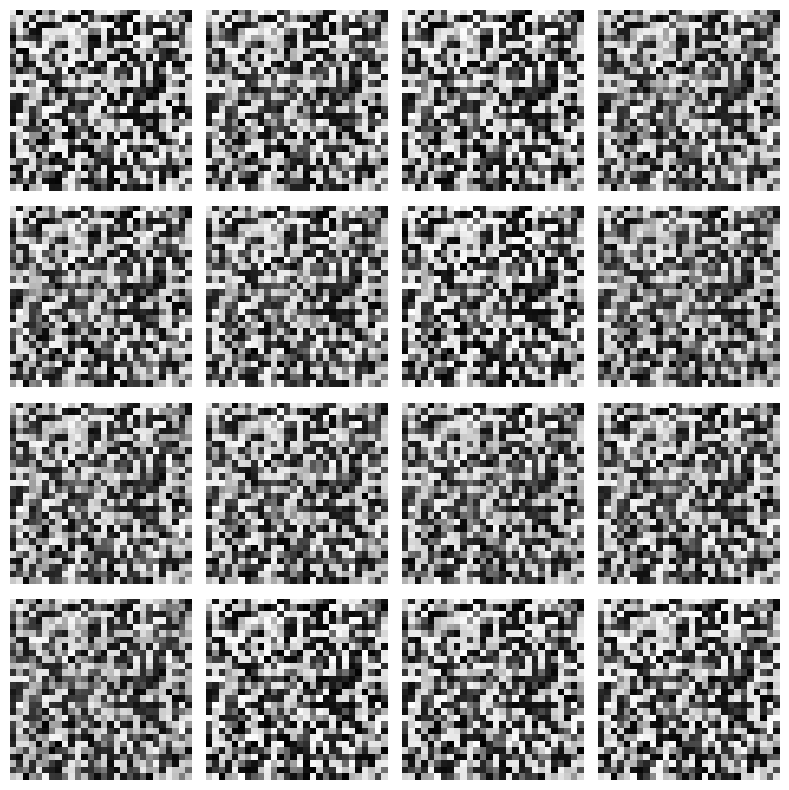

In [10]:
plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        generated_images[i].reshape(28,28),
        cmap='gray'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# This assignment demonstrated the use of a Generative Adversarial Network (GAN) to generate fashion product images using the Fashion-MNIST dataset.
The Generator learned to create realistic fashion images from random noise, while the Discriminator learned to distinguish real images from generated ones.
As training progressed, the quality of generated images improved, showing the effectiveness of GANs in image generation tasks.